# Paddy crop phenology — visualization

Loads output from `phenology_pipeline` and plots:

1. **Summary** — stage, GDD, dates, confidence, flags
2. **Satellite curves** — NDVI (S2) + VH (S1) with key dates
3. **GDD progression** — cumulative GDD vs D-6072 stage bands
4. **Farm map** — polygon location

Run the pipeline first (`examples/run_phenology.py`) or use the optional run cell below.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Project root = parent of notebooks/
ROOT = Path.cwd().resolve()
if not (ROOT / "phenology_pipeline").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from phenology_pipeline.config import DEFAULT_GDD_STAGES

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

print("Project root:", ROOT)

Project root: /Users/mipl/Documents/Regen_ag/Crop_stage


In [2]:
# ── User settings ───────────────────────────────────────────────────────────

FARM_ID = 1
OUTPUT_DIR = ROOT / "phenology_output" / "awd_test"
POLYGON_PATH = '/Users/mipl/Downloads/awd_farms.geojson'

# Set RUN_PIPELINE = True to execute STAC + ERA5 (needs CDS + Planetary Computer)
RUN_PIPELINE = True

PIPELINE_KWARGS = dict(
    polygon_path=str(POLYGON_PATH),
    farm_id=FARM_ID,
    farm_id_col="fid",
    output_dir=str(OUTPUT_DIR),
    download_start="2026-05-01",
    download_end="2026-08-31",
    peak_search_end="2026-08-10",
    date_confidence="uncertain",
    download_data=True,
    timeseries_cache_dir=str(OUTPUT_DIR / "stac_download"),
)

JSON_PATH = OUTPUT_DIR / f"phenology_{FARM_ID}.json"
TS_PATH = OUTPUT_DIR / f"phenology_timeseries_{FARM_ID}.csv"

In [3]:
if RUN_PIPELINE:
    from phenology_pipeline.config import PhenologyConfig
    from phenology_pipeline.phenology_engine import run_phenology

    cfg = PhenologyConfig(**PIPELINE_KWARGS)
    result = run_phenology(cfg, assessment_date="2026-05-01")
    JSON_PATH = Path(result["output_json"])
    TS_PATH = Path(result["output_timeseries_csv"])
    print("Pipeline finished:", JSON_PATH)
elif not JSON_PATH.exists():
    # Demo data so charts work before first STAC/ERA5 run
    print("No saved results — generating demo timeseries for visualization")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    dates = pd.date_range("2026-05-01", "2026-08-31", freq="12D")
    t = np.arange(len(dates))
    transplant_demo = pd.Timestamp("2026-05-01")
    demo_ts = pd.DataFrame({
        "date": dates,
        "ndvi": 0.12 + 0.65 * (1 - np.exp(-t / 5)),
        "vh": -19 + 9 * (1 - np.exp(-t / 4)),
        "unified": 0.12 + 0.65 * (1 - np.exp(-t / 5)),
        "cumulative_gdd": np.clip((dates - transplant_demo).days * 14, 0, 1650),
    })
    demo_ts.to_csv(TS_PATH, index=False)
    demo_summary = {
        "farm_id": FARM_ID,
        "assessment_date": "2026-05-01",
        "mode": "demo",
        "used_transplant": str(transplant_demo.date()),
        "transplant_source": "demo",
        "estimated_transplant": str(transplant_demo.date()),
        "estimated_sowing": str((transplant_demo - pd.Timedelta(days=28)).date()),
        "cumulative_gdd": 980.0,
        "days_after_transplant": 103,
        "current_stage": "reproductive",
        "stage_confidence": 0.75,
        "satellite_stage_hint": "reproductive",
        "estimated_harvest_date": "2026-12-01",
        "data_source_mix": {"S2": 8, "S1": 6, "missing": 1},
        "anomaly_flags": [],
        "phenology_features": {"ndvi": {}, "vh": {}},
        "era5_centroid": {"lat": 11.74, "lon": 79.69},
    }
    with open(JSON_PATH, "w") as f:
        json.dump(demo_summary, f, indent=2)
else:
    print("Loading existing results from", OUTPUT_DIR)

Using cached STAC output: /Users/mipl/Documents/Regen_ag/Crop_stage/phenology_output/awd_test/stac_download/20260831_162459_511224
Pipeline finished: /Users/mipl/Documents/Regen_ag/Crop_stage/phenology_output/awd_test/phenology_1.json


In [4]:
with open(JSON_PATH) as f:
    summary = json.load(f)

ts = pd.read_csv(TS_PATH, parse_dates=["date"])
gdf = gpd.read_file(POLYGON_PATH)
if FARM_ID and "farm_id" in gdf.columns:
    gdf = gdf[gdf["farm_id"].astype(str) == str(FARM_ID)]

transplant = pd.Timestamp(summary["used_transplant"])
assessment = pd.Timestamp(summary["assessment_date"])
harvest = pd.Timestamp(summary["estimated_harvest_date"])

summary

{'farm_id': '1',
 'assessment_date': '2026-05-01',
 'mode': 'uncertain',
 'provided_transplant': None,
 'estimated_transplant': '2026-07-07',
 'used_transplant': '2026-07-07',
 'transplant_source': 'fused_vh_ndvi',
 'provided_sowing': None,
 'estimated_sowing': '2026-06-09',
 'cumulative_gdd': 0.0,
 'days_after_transplant': -67,
 'current_stage': 'pre_transplant',
 'stage_confidence': 0.65,
 'gdd_stage_margin': 0.0,
 'satellite_stage_hint': 'pre_transplant',
 'estimated_harvest_date': '2026-11-04',
 'data_source_mix': {'S2': 7, 'S1': 10, 'missing': 3},
 'pixel_heterogeneity': {'error': "'PosixPath' object has no attribute 'copy'"},
 'anomaly_flags': ['assessment_before_transplant'],
 'phenology_features': {'ndvi': {'greenup_day_abs': 72.0,
   'peak_day_abs': 100.0,
   'season_peak_used': True,
   'peak_method': 'season_peak',
   'peak_ndvi': 0.36527152146611924,
   'baseline_ndvi': 0.1074716245489462,
   'amplitude_ndvi': 0.25779989691717303,
   'season_integral': 22.561157181859034,
 

In [5]:
def summary_table(s: dict) -> pd.DataFrame:
    rows = [
        ("Farm ID", s["farm_id"]),
        ("Assessment date", s["assessment_date"]),
        ("Mode", s["mode"]),
        ("Used transplant", s["used_transplant"]),
        ("Transplant source", s["transplant_source"]),
        ("Estimated transplant", s.get("estimated_transplant")),
        ("Estimated sowing", s.get("estimated_sowing")),
        ("Days after transplant", s["days_after_transplant"]),
        ("Cumulative GDD (°C)", s["cumulative_gdd"]),
        ("Current stage", s["current_stage"]),
        ("Stage confidence", s["stage_confidence"]),
        ("Satellite stage hint", s["satellite_stage_hint"]),
        ("Est. harvest", s["estimated_harvest_date"]),
        ("Data mix (S2/S1/missing)", str(s.get("data_source_mix", {}))),
        ("Anomaly flags", ", ".join(s.get("anomaly_flags", [])) or "none"),
    ]
    het = s.get("pixel_heterogeneity") or {}
    if het:
        rows.append(("Pixel heterogeneity", het))
    return pd.DataFrame(rows, columns=["Field", "Value"]).set_index("Field")

display(summary_table(summary))

,Value
Field,
Farm ID,1
Assessment date,2026-05-01
Mode,uncertain
Used transplant,2026-07-07
Transplant source,fused_vh_ndvi
Estimated transplant,2026-07-07
Estimated sowing,2026-06-09
Days after transplant,-67
Cumulative GDD (°C),0.0


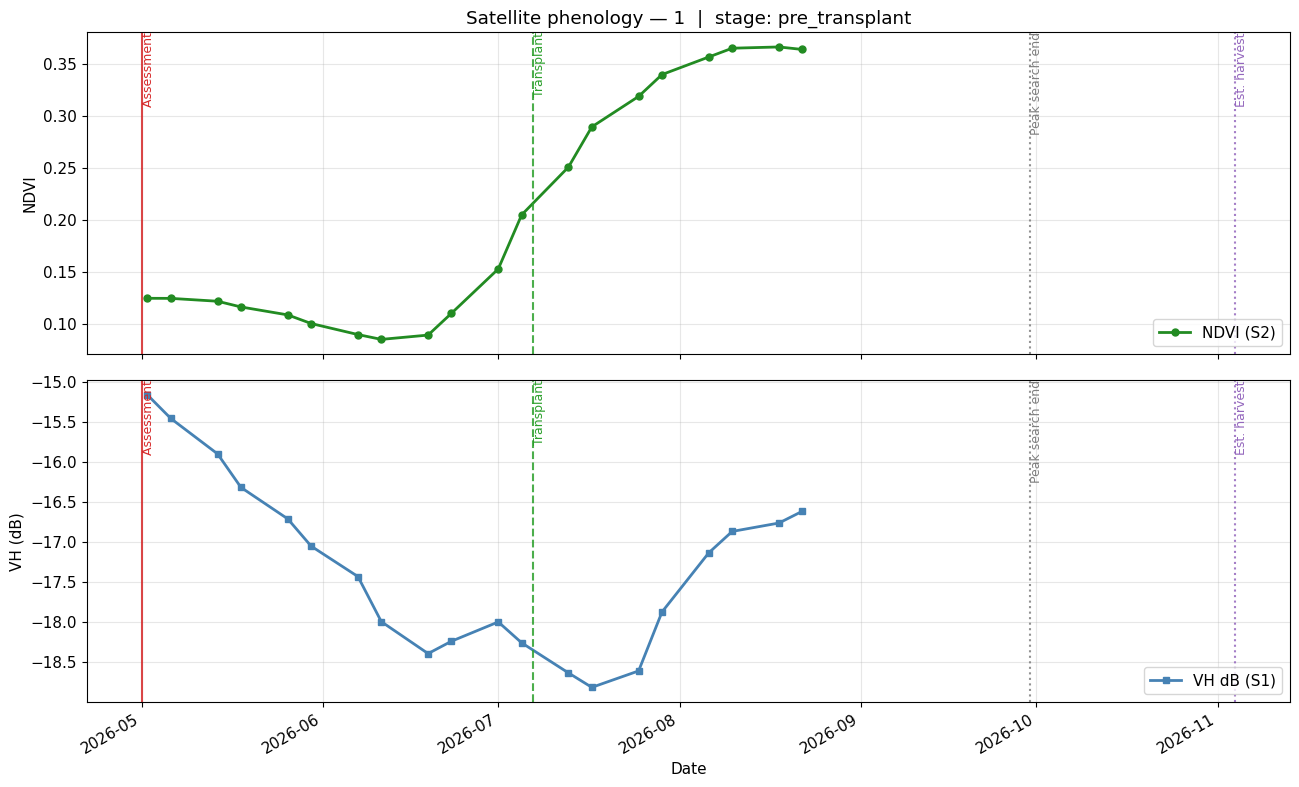

In [6]:
STAGE_COLORS = {
    "establishment": "#c6dbef",
    "vegetative": "#9ecae1",
    "panicle_initiation": "#6baed6",
    "reproductive": "#fdae6b",
    "ripening": "#fd8d3c",
    "maturity": "#e6550d",
}


def add_date_markers(ax, dates: dict[str, pd.Timestamp], ylim=None):
    styles = {
        "transplant": ("tab:green", "--", "Transplant"),
        "assessment": ("tab:red", "-", "Assessment"),
        "harvest": ("tab:purple", ":", "Est. harvest"),
        "peak_search_end": ("tab:gray", ":", "Peak search end"),
    }
    if ylim is None:
        ylim = ax.get_ylim()
    for key, (color, ls, label) in styles.items():
        if key not in dates or pd.isna(dates[key]):
            continue
        ax.axvline(dates[key], color=color, ls=ls, lw=1.5, alpha=0.85)
        ax.text(
            dates[key],
            ylim[1],
            f" {label}",
            color=color,
            fontsize=9,
            va="top",
            rotation=90,
        )


key_dates = {
    "transplant": transplant,
    "assessment": assessment,
    "harvest": harvest,
    "peak_search_end": pd.Timestamp(f"{transplant.year}-09-30"),
}

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# NDVI
ax0 = axes[0]
ax0.plot(ts["date"], ts["ndvi"], "o-", color="forestgreen", lw=2, ms=5, label="NDVI (S2)")
ax0.set_ylabel("NDVI")
ax0.set_title(f"Satellite phenology — {summary['farm_id']}  |  stage: {summary['current_stage']}")
ax0.legend(loc="lower right")
add_date_markers(ax0, key_dates)

# VH
ax1 = axes[1]
ax1.plot(ts["date"], ts["vh"], "s-", color="steelblue", lw=2, ms=5, label="VH dB (S1)")
ax1.set_ylabel("VH (dB)")
ax1.set_xlabel("Date")
ax1.legend(loc="lower right")
add_date_markers(ax1, key_dates)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

2026-08-31 17:03:18,830 INFO Request ID is 20a5e795-7f5c-46fe-9b9b-db0773be711e
2026-08-31 17:03:19,041 INFO status has been updated to accepted
Recovering from connection error [HTTPSConnectionPool(host='cds.climate.copernicus.eu', port=443): Read timed out. (read timeout=60)], attempt 1 of 500
Retrying in 120 seconds
Recovering from connection error [HTTPSConnectionPool(host='cds.climate.copernicus.eu', port=443): Read timed out. (read timeout=60)], attempt 1 of 500
Retrying in 120 seconds
Recovering from connection error [('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))], attempt 1 of 500
Retrying in 120 seconds
Recovering from connection error [('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))], attempt 1 of 500
Retrying in 120 seconds
2026-08-31 22:13:46,203 INFO status has been updated to successful


6d7367462b90f2bd93d90cecd09a1a8a.nc:   0%|          | 0.00/24.6k [00:00<?, ?B/s]

2026-08-31 22:13:48,926 INFO Request ID is 447724df-5601-460d-9ed0-c790a1391543
2026-08-31 22:13:49,137 INFO status has been updated to accepted
Recovering from connection error [HTTPSConnectionPool(host='cds.climate.copernicus.eu', port=443): Read timed out. (read timeout=60)], attempt 1 of 500
Retrying in 120 seconds
2026-08-31 23:30:58,985 INFO status has been updated to successful


207f01d186209f39aed9e0edcd4adc64.nc:   0%|          | 0.00/24.6k [00:00<?, ?B/s]

ERA5 daily fetch skipped (use cached or run pipeline): CDS ERA5-Land request failed for 2026-09 (daily_minimum). Check ~/.cdsapirc credentials and request parameters. Underlying error: 400 Client Error: Bad Request for url: https://cds.climate.copernicus.eu/api/retrieve/v1/processes/derived-era5-land-daily-statistics/execution
invalid request
None of the data you have requested is available yet, please revise the period requested. The latest date available for this dataset is: 2026-08-26 18:00


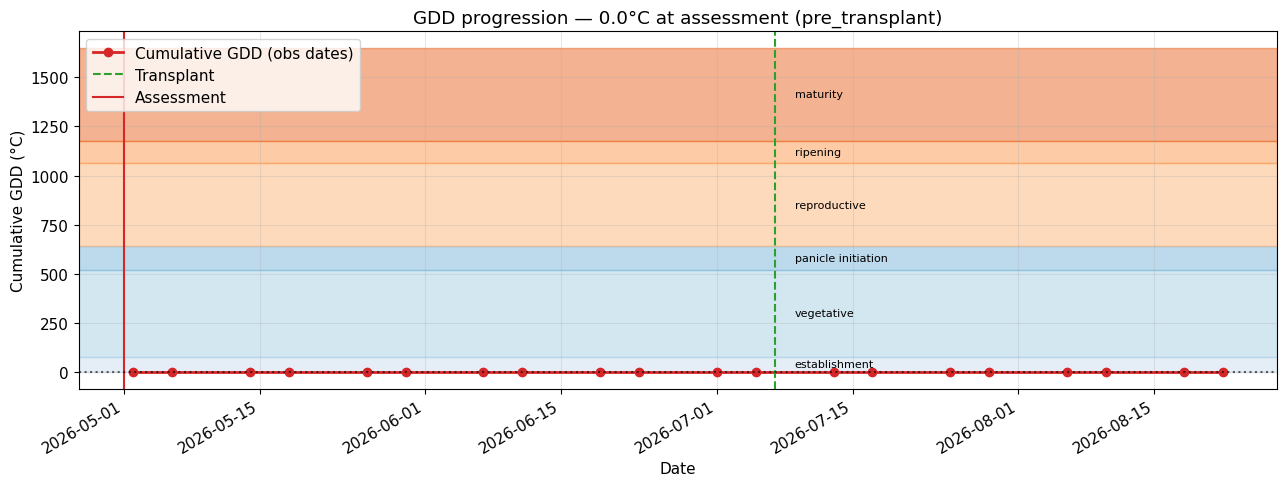

In [7]:
# GDD curve with stage bands
from phenology_pipeline.gdd import fetch_era5_land_tmin_tmax, gdd_table_from_transplant

centroid = summary.get("era5_centroid", {})
lat, lon = centroid.get("lat"), centroid.get("lon")
if lat is None:
    c = gdf.to_crs(4326).geometry.union_all().centroid
    lat, lon = c.y, c.x

try:
    weather = fetch_era5_land_tmin_tmax(
        lat, lon, transplant, harvest + pd.Timedelta(days=7),
        cache_dir=ROOT / ".cache" / "phenology" / "era5",
    )
    gdd_df = gdd_table_from_transplant(weather, transplant, t_base=10.0)
    has_daily_gdd = True
except Exception as exc:
    print("ERA5 daily fetch skipped (use cached or run pipeline):", exc)
    gdd_df = None
    has_daily_gdd = False

fig, ax = plt.subplots(figsize=(13, 5))

for st in DEFAULT_GDD_STAGES:
    ax.axhspan(st.gdd_min, st.gdd_max, color=STAGE_COLORS.get(st.name, "#eee"), alpha=0.45)
    ax.text(
        transplant + pd.Timedelta(days=2),
        (st.gdd_min + st.gdd_max) / 2,
        st.name.replace("_", " "),
        fontsize=8,
        va="center",
    )

if has_daily_gdd and gdd_df is not None:
    ax.plot(gdd_df.index, gdd_df["cumulative_gdd"], color="tab:red", lw=2.5, label="Cumulative GDD")
else:
    ax.plot(ts["date"], ts["cumulative_gdd"], "o-", color="tab:red", lw=2, label="Cumulative GDD (obs dates)")

ax.axvline(transplant, color="tab:green", ls="--", label="Transplant")
ax.axvline(assessment, color="tab:red", ls="-", label="Assessment")
ax.axhline(summary["cumulative_gdd"], color="black", ls=":", alpha=0.6)

ax.set_ylabel("Cumulative GDD (°C)")
ax.set_xlabel("Date")
ax.set_title(f"GDD progression — {summary['cumulative_gdd']}°C at assessment ({summary['current_stage']})")
ax.legend(loc="upper left")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

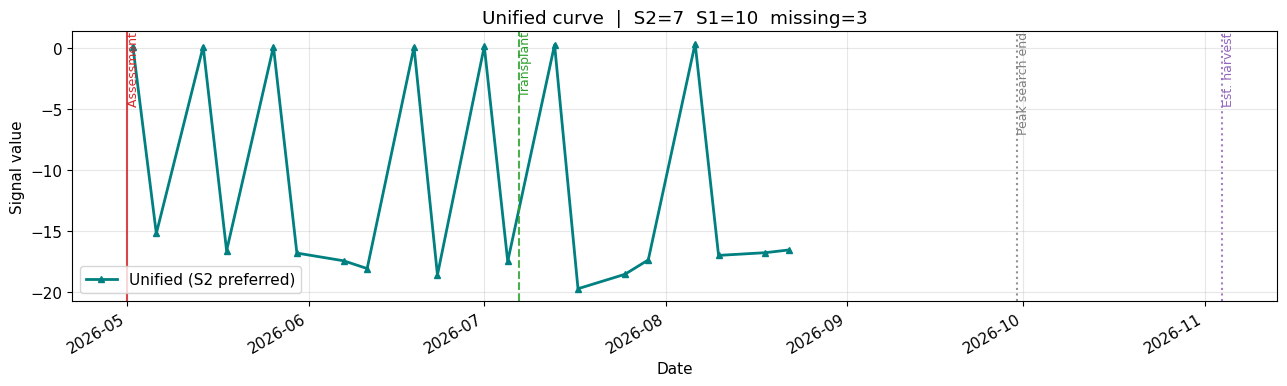

In [8]:
# Unified signal + source mix
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ts["date"], ts["unified"], "^-", color="teal", lw=2, ms=5, label="Unified (S2 preferred)")
mix = summary.get("data_source_mix", {})
ax.set_title(
    f"Unified curve  |  S2={mix.get('S2', 0)}  S1={mix.get('S1', 0)}  missing={mix.get('missing', 0)}"
)
ax.set_ylabel("Signal value")
ax.set_xlabel("Date")
add_date_markers(ax, key_dates)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [ ]:
# Farm location map
try:
    import folium

    gdf_wgs = gdf.to_crs(4326)
    bounds = gdf_wgs.total_bounds
    center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]

    m = folium.Map(location=center, zoom_start=15, tiles="OpenStreetMap")
    folium.GeoJson(
        gdf_wgs.__geo_interface__,
        name="Farm polygon",
        style_function=lambda _: {"color": "#2ca25f", "weight": 2, "fillOpacity": 0.25},
        tooltip=f"{FARM_ID} | {summary['current_stage']}",
    ).add_to(m)
    folium.Marker(
        [lat, lon],
        popup=f"ERA5 centroid\nGDD={summary['cumulative_gdd']}°C",
        icon=folium.Icon(color="red", icon="info-sign"),
    ).add_to(m)
    m.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])
    display(m)
except ImportError:
    print("Install folium for interactive map: pip install folium")
    ax = gdf.to_crs(4326).plot(edgecolor="green", facecolor="lightgreen", alpha=0.4, figsize=(6, 6))
    ax.set_title(f"Farm polygon — {FARM_ID}")
    plt.show()

In [ ]:
# Phenology features from pipeline JSON
feat = summary.get("phenology_features", {})
if feat:
    display(pd.DataFrame({
        "NDVI": feat.get("ndvi", {}),
        "VH": feat.get("vh", {}),
    }).T)